# 02b — EDA: Chẩn đoán nguyên nhân

Phần 2/4 của EDA (tách từ `02_eda.ipynb` gốc — xem `docs/analysis/EDA_FINDINGS.md` cho phân tích đầy đủ). Phạm vi: khách mới/cũ, thất thoát gross→net, cơ chế khuyến mãi, vì sao 2019 sụt (ASP vs volume, bán dưới giá vốn).

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")  # notebook vẫn hiện inline qua %matplotlib inline bên dưới
import matplotlib.pyplot as plt
from lunardate import LunarDate

from datathon import config
from datathon.ingestion import load_raw

%matplotlib inline

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

C_REV, C_COGS, C_GRAY, C_ACCENT = "#A32D2D", "#185FA5", "#888780", "#534AB7"
PALETTE = ["#185FA5", "#A32D2D", "#3B6D11", "#BA7517", "#534AB7", "#993556"]
AGE_ORDER = ["18-24", "25-34", "35-44", "45-54", "55+"]

plt.rcParams.update({"font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "grid.linestyle": ":"})

print("DATA_RAW:", config.DATA_RAW)


DATA_RAW: /Users/lhoanghai_/Documents/Study/Dự án datathon2026/data/raw


In [2]:
import os
import trino

_trino_conn = trino.dbapi.connect(
    host=os.environ.get("TRINO_HOST", "localhost"),
    port=int(os.environ.get("TRINO_PORT", "8080")),
    user="notebook_02_eda",
    catalog="iceberg",
    schema="staging",
)
sales = pd.read_sql(
    "SELECT date AS \"Date\", revenue AS \"Revenue\", cogs AS \"COGS\" "
    "FROM mart_revenue_daily ORDER BY date",
    _trino_conn,
)
sales["Date"] = pd.to_datetime(sales["Date"])
assert len(sales) == 3833, f"mart_revenue_daily phải 3833 dòng, đang {len(sales)}"
orders = load_raw("orders")
items = load_raw("order_items")
products = load_raw("products")
customers = load_raw("customers")
geography = load_raw("geography")
promotions = load_raw("promotions")
returns = load_raw("returns")
payments = load_raw("payments")

for name, df in [("sales", sales), ("orders", orders), ("order_items", items),
                  ("products", products), ("customers", customers),
                  ("geography", geography), ("promotions", promotions),
                  ("returns", returns), ("payments", payments)]:
    print(f"{name:14s} {df.shape}")


sales          (3833, 3)
orders         (646945, 8)
order_items    (714669, 7)
products       (2412, 8)
customers      (121930, 7)
geography      (39948, 4)
promotions     (50, 10)
returns        (39939, 7)
payments       (646945, 4)


In [3]:
# customers đã có sẵn cột 'zip' (khác bản gốc chỉ usecols acquisition_channel/signup_date) ->
# drop trước khi merge để tránh đụng 'zip' đã có từ orders (tránh bị pandas tự suffix zip_x/zip_y).
customers_nozip = customers.drop(columns=["zip"])

li = (items
      .merge(orders, on="order_id", how="left")
      .merge(products, on="product_id", how="left")
      .merge(customers_nozip, on="customer_id", how="left")
      .merge(geography, on="zip", how="left")
      .merge(promotions, on="promo_id", how="left"))

li["line_revenue"] = li["quantity"] * li["unit_price"]
li["line_cogs"] = li["quantity"] * li["cogs"]
li["year"] = li["order_date"].dt.year
li["month"] = li["order_date"].dt.month
li = li[li["year"].between(2013, 2022)].copy()

chk = li.groupby(li["order_date"])["line_revenue"].sum()
sales_idx = sales.set_index("Date")["Revenue"]
diff = ((chk.reindex(sales_idx.index) - sales_idx).abs() / sales_idx).mean() * 100
print(f"Sanity check — sai lệch rebuilt (line_revenue) vs sales.csv: {diff:.3f}% (kỳ vọng ~0%)")
print(f"{len(li):,} dòng sau join, {li['customer_id'].nunique():,} khách")


Sanity check — sai lệch rebuilt (line_revenue) vs sales.csv: 0.000% (kỳ vọng ~0%)
677,662 dòng sau join, 89,063 khách


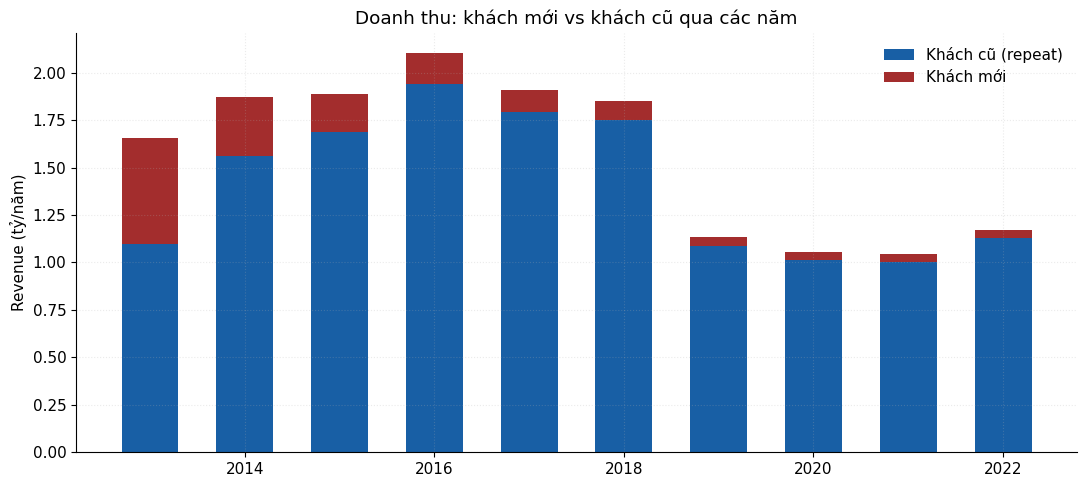

Tỷ trọng revenue từ khách cũ (repeat): {2013: np.float64(66.1), 2018: np.float64(94.7), 2019: np.float64(95.6), 2022: np.float64(96.4)}


In [4]:
first_order = orders.groupby("customer_id")["order_date"].min().rename("first_order_date")
li2 = li.merge(first_order, on="customer_id", how="left")
li2["cust_type"] = np.where(li2["order_date"] == li2["first_order_date"], "Khách mới", "Khách cũ (repeat)")
nr_yr = li2.groupby(["year", "cust_type"])["line_revenue"].sum().unstack() / 1e9

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(nr_yr.index, nr_yr["Khách cũ (repeat)"], color=C_COGS, label="Khách cũ (repeat)", width=0.6)
ax.bar(nr_yr.index, nr_yr["Khách mới"], bottom=nr_yr["Khách cũ (repeat)"], color=C_REV, label="Khách mới", width=0.6)
ax.set_ylabel("Revenue (tỷ/năm)")
ax.set_title("Doanh thu: khách mới vs khách cũ qua các năm")
ax.legend(frameon=False)
fig.tight_layout(); plt.show()

repeat_share = (nr_yr["Khách cũ (repeat)"] / nr_yr.sum(axis=1) * 100)
print("Tỷ trọng revenue từ khách cũ (repeat):",
      {y: round(repeat_share.loc[y], 1) for y in [2013, 2018, 2019, 2022]})


% doanh thu từ khách cũ tăng 66.1%→96.4% (2013→2022) — khách mới gần như biến mất từ 2018, không phải khách cũ trung thành hơn.

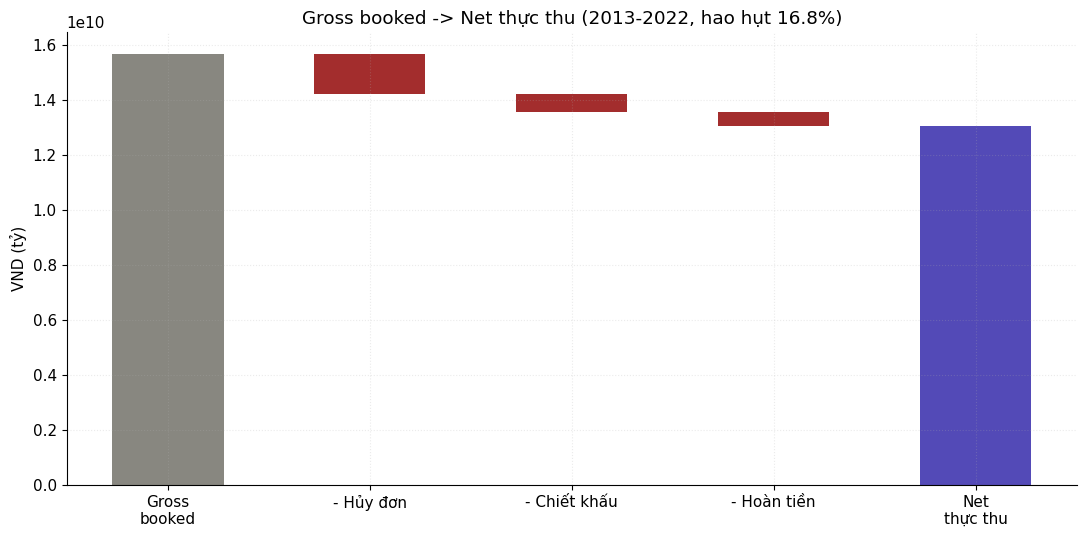

Gross booked   :    15.69 tỷ
- Hủy đơn      :    -1.45 tỷ (9.2%)
- Chiết khấu   :    -0.68 tỷ (4.3%)
- Hoàn tiền    :    -0.51 tỷ (3.3%)
= Net thực thu :    13.05 tỷ (83.2% của gross)


In [5]:
gross = li["line_revenue"].sum()
cancelled_loss = li.loc[li["order_status"] == "cancelled", "line_revenue"].sum()
after_cancel = gross - cancelled_loss
discount_loss = li.loc[li["order_status"] != "cancelled", "discount_amount"].sum()
after_discount = after_cancel - discount_loss
refund_loss = returns["refund_amount"].sum()
net_final = after_discount - refund_loss

stages = ["Gross\nbooked", "- Hủy đơn", "- Chiết khấu", "- Hoàn tiền", "Net\nthực thu"]
bar_bottoms = [0, after_cancel, after_discount, net_final, 0]
bar_heights = [gross, cancelled_loss, discount_loss, refund_loss, net_final]
colors = [C_GRAY, C_REV, C_REV, C_REV, C_ACCENT]

fig, ax = plt.subplots(figsize=(11, 5.5))
for i, (s, h, c) in enumerate(zip(bar_bottoms, bar_heights, colors)):
    ax.bar(i, h, bottom=s, color=c, width=0.55)
ax.set_xticks(range(5), stages)
ax.set_ylabel("VND (tỷ)")
ax.set_title(f"Gross booked -> Net thực thu (2013-2022, hao hụt {(1-net_final/gross)*100:.1f}%)")
fig.tight_layout(); plt.show()

print(f"Gross booked   : {gross/1e9:8.2f} tỷ")
print(f"- Hủy đơn      : {-cancelled_loss/1e9:8.2f} tỷ ({cancelled_loss/gross*100:.1f}%)")
print(f"- Chiết khấu   : {-discount_loss/1e9:8.2f} tỷ ({discount_loss/gross*100:.1f}%)")
print(f"- Hoàn tiền    : {-refund_loss/1e9:8.2f} tỷ ({refund_loss/gross*100:.1f}%)")
print(f"= Net thực thu : {net_final/1e9:8.2f} tỷ ({net_final/gross*100:.1f}% của gross)")


Gross 15.69 tỷ → Net 13.05 tỷ (83.2%). Hủy đơn là tầng hao hụt lớn nhất (-9.2%), tỷ lệ ổn định ±0.6 điểm % suốt 10 năm — không xấu đi theo thời gian.

## Khuyến mãi & lỗ gộp

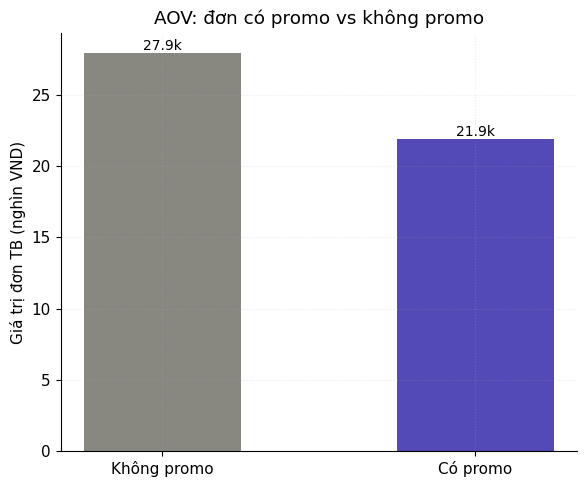

AOV không promo: 27,945 VND | AOV có promo: 21,896 VND (chênh -21.6%)


In [6]:
li["has_promo"] = li["promo_id"].notna()
order_val = li.groupby(["order_id", "has_promo"])["line_revenue"].sum().reset_index()
aov = order_val.groupby("has_promo")["line_revenue"].mean()

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(["Không promo", "Có promo"], aov.values / 1e3, color=[C_GRAY, C_ACCENT], width=0.5)
for i, v in enumerate(aov.values / 1e3):
    ax.text(i, v, f"{v:.1f}k", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Giá trị đơn TB (nghìn VND)")
ax.set_title("AOV: đơn có promo vs không promo")
fig.tight_layout(); plt.show()

print(f"AOV không promo: {aov[False]:,.0f} VND | AOV có promo: {aov[True]:,.0f} VND "
      f"(chênh {(aov[True]/aov[False]-1)*100:+.1f}%)")


AOV không-promo (27.9k) CAO HƠN có-promo (21.9k) 21.6% — đây là tương quan, không phải quan hệ nhân quả (promo tập trung ở SKU giá thấp).

## Q1 — Vì sao 2019-2021 sụt mạnh?

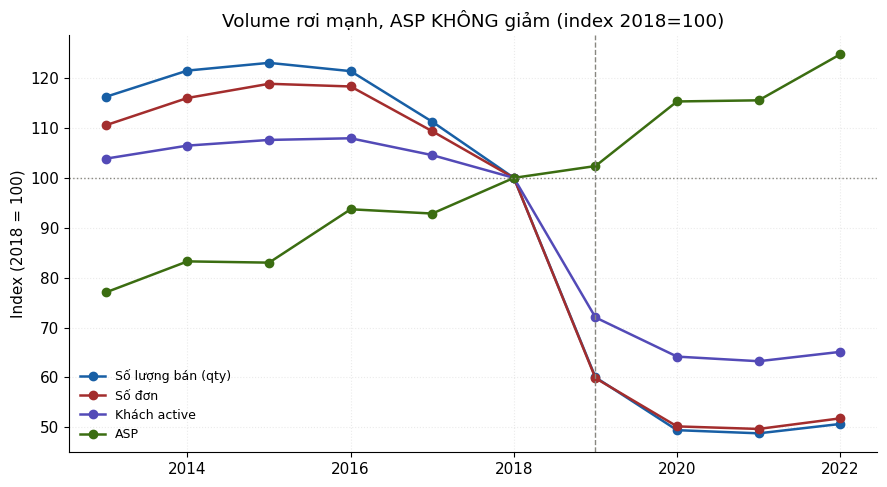

2018->2019: Revenue -38.6% | ASP +2.4% | Qty -40.0% | Số đơn -40.2% | Khách active -28.0%
-> ASP KHÔNG giảm; sụt giảm gần như toàn bộ đến từ khối lượng (qty/số đơn) + khách active rơi.


In [7]:
yr_kpi = li.groupby("year").agg(revenue=("line_revenue", "sum"), qty=("quantity", "sum")).reset_index()
yr_kpi["ASP"] = yr_kpi["revenue"] / yr_kpi["qty"]

ord_all = orders.assign(year=orders["order_date"].dt.year)
ord_all = ord_all[ord_all["year"].between(2013, 2022)]
n_orders = ord_all.groupby("year")["order_id"].nunique().rename("n_orders")
n_active_cust = ord_all.groupby("year")["customer_id"].nunique().rename("n_active_cust")
yr_kpi = yr_kpi.merge(n_orders, on="year").merge(n_active_cust, on="year")
yr_kpi["AOV"] = yr_kpi["revenue"] / yr_kpi["n_orders"]
base = yr_kpi.set_index("year")

idx100 = base / base.loc[2018] * 100
fig, ax = plt.subplots(figsize=(9, 5))
for col, c, lbl in [("qty", C_COGS, "Số lượng bán (qty)"), ("n_orders", C_REV, "Số đơn"),
                     ("n_active_cust", C_ACCENT, "Khách active"), ("ASP", "#3B6D11", "ASP")]:
    ax.plot(base.index, idx100[col], "o-", color=c, lw=1.8, label=lbl)
ax.axhline(100, color=C_GRAY, ls=":", lw=1)
ax.axvline(2019, color=C_GRAY, ls="--", lw=1)
ax.set_ylabel("Index (2018 = 100)")
ax.set_title("Volume rơi mạnh, ASP KHÔNG giảm (index 2018=100)")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout(); plt.show()

r18, r19 = base.loc[2018], base.loc[2019]
print(f"2018->2019: Revenue {(r19['revenue']/r18['revenue']-1)*100:+.1f}% | "
      f"ASP {(r19['ASP']/r18['ASP']-1)*100:+.1f}% | Qty {(r19['qty']/r18['qty']-1)*100:+.1f}% | "
      f"Số đơn {(r19['n_orders']/r18['n_orders']-1)*100:+.1f}% | "
      f"Khách active {(r19['n_active_cust']/r18['n_active_cust']-1)*100:+.1f}%")
print("-> ASP KHÔNG giảm; sụt giảm gần như toàn bộ đến từ khối lượng (qty/số đơn) + khách active rơi.")


2018→2019: ASP TĂNG +2.4% trong khi Revenue -38.6% — sụt hoàn toàn do khối lượng (Qty -40%, số đơn/khách active -28%), không phải giảm giá.

## Q2 — Cơ chế lỗ gộp

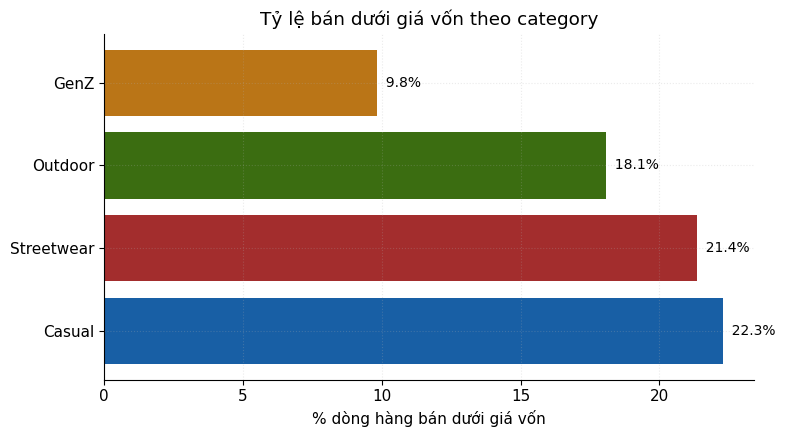

% dòng bán dưới giá vốn KHI có promo    : 47.86%
% dòng bán dưới giá vốn KHI KHÔNG có promo: 0.18%
-> promotion là nguyên nhân trực tiếp cơ chế lỗ gộp (bán dưới giá vốn tập trung ở dòng có promo).


In [8]:
li["below_cost"] = li["unit_price"] < li["cogs"]
overall_bc_promo = li.loc[li["has_promo"], "below_cost"].mean() * 100
overall_bc_nopromo = li.loc[~li["has_promo"], "below_cost"].mean() * 100

bc_cat = li.groupby("category").agg(
    n_lines=("below_cost", "size"),
    pct_lineitems_below_cost=("below_cost", "mean"),
).reset_index()
bc_cat["pct_lineitems_below_cost"] *= 100
bc_cat = bc_cat.sort_values("pct_lineitems_below_cost", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(bc_cat["category"], bc_cat["pct_lineitems_below_cost"], color=PALETTE[:len(bc_cat)])
for i, v in enumerate(bc_cat["pct_lineitems_below_cost"]):
    ax.text(v, i, f"  {v:.1f}%", va="center", fontsize=10)
ax.set_xlabel("% dòng hàng bán dưới giá vốn")
ax.set_title("Tỷ lệ bán dưới giá vốn theo category")
fig.tight_layout(); plt.show()

print(f"% dòng bán dưới giá vốn KHI có promo    : {overall_bc_promo:.2f}%")
print(f"% dòng bán dưới giá vốn KHI KHÔNG có promo: {overall_bc_nopromo:.2f}%")
print("-> promotion là nguyên nhân trực tiếp cơ chế lỗ gộp (bán dưới giá vốn tập trung ở dòng có promo).")


Dòng có promo bán dưới giá vốn 47.86% thời gian vs không-promo chỉ 0.18% (chênh 266 lần) — promotion pricing là nguyên nhân trực tiếp cơ chế lỗ gộp.